In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

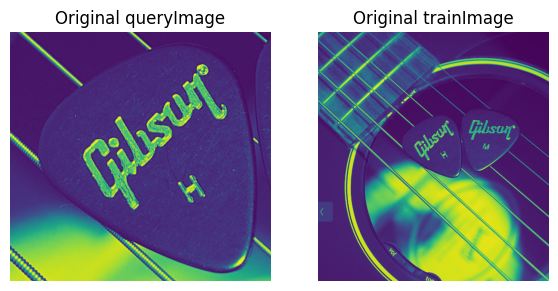

In [2]:
query_path = "queryImage.png"
train_path = "trainImage.png"

query_img = cv2.imread(query_path, 0)
train_img = cv2.imread(train_path, 0)

if query_img is None:
    raise FileNotFoundError("Can't read query image, please check query_path")

if train_img is None:
    raise FileNotFoundError("Can't read train image, please check train_path")

# query_rgb = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)
# train_rgb = cv2.cvtColor(train_img, cv2.COLOR_BGR2RGB)

# Show images
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(query_img)
axes[0].set_title("Original queryImage")
axes[0].axis("off")

axes[1].imshow(train_img)
axes[1].set_title("Original trainImage")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [3]:
def show_image(title, image_bgr):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(2, 2))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

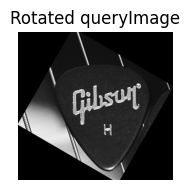

In [4]:
def rotate_image(image, angle=30, scale=1.0):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, scale)
    rotated = cv2.warpAffine(image, M, (w, h))

    return rotated

query_rotated = rotate_image(query_img, angle= -30, scale=0.75)
show_image("Rotated queryImage", query_rotated)

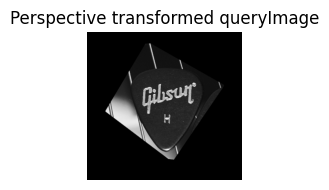

Perspective transform matrix:
[[ 5.93812969e-01 -5.37003374e-02  6.35999985e+01]
 [-5.62546572e-02  6.92371081e-01  4.05000000e+01]
 [-4.13941567e-04 -2.88938039e-05  1.00000000e+00]]


In [5]:
def perspective_transform(image):
    h, w = image.shape[:2]

    src_pts = np.float32([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ])

    dst_pts = np.float32([
        [0.15 * w, 0.10 * h],
        [0.90 * w, 0.05 * h],
        [0.85 * w, 0.90 * h],
        [0.10 * w, 0.80 * h]
    ])

    H = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(image, H, (w, h))

    return warped, H

perspective, H = perspective_transform(query_rotated)

show_image("Perspective transformed queryImage", perspective)

print("Perspective transform matrix:")
print(H)

In [21]:
MIN_MATCH_COUNT = 10

# Initiate SIFT detector - OpenCV mới
sift = cv2.SIFT_create()

# Find keypoints and descriptors
kp1, des1 = sift.detectAndCompute(query_rotated, None)
kp2, des2 = sift.detectAndCompute(train_img, None)

print("Number of keypoints in query image:", len(kp1))
print("Number of keypoints in train image:", len(kp2))

if des1 is None or des2 is None:
    raise ValueError("Không tìm được descriptor. Ảnh có thể quá ít texture hoặc bị blur quá mạnh.")

# FLANN matcher for SIFT
FLANN_INDEX_KDTREE = 1

index_params = dict(
    algorithm=FLANN_INDEX_KDTREE,
    trees=5
)

search_params = dict(
    checks=50
)

flann = cv2.FlannBasedMatcher(index_params, search_params)

# SIFT descriptors cần float32
# des1 = np.float32(des1)
# des2 = np.float32(des2)

matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good = []

for pair in matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < 0.7 * n.distance:
            good.append(m)
# Lowe's ratio threshold = 0.7
# Idea: if m/n smaller than 0.7 is enough clear difference. Can decrease 0.7 to more strictly compare. 

print("Good matches:", len(good))

Number of keypoints in query image: 349
Number of keypoints in train image: 548
Good matches: 54


In [19]:
def visualize_homography_result(
    query_img,
    train_img,
    kp1,
    kp2,
    good,
    H=None,
    mask=None,
    min_match_count=10,
    max_matches=80
):
    """
    Visualize Feature Matching + Homography result.

    query_img: ảnh query
    train_img: ảnh train
    kp1: keypoints của query_img
    kp2: keypoints của train_img
    good: list good matches
    H: Homography matrix
    mask: mask từ cv2.findHomography()
    """

    # Convert train image sang BGR để vẽ màu
    if len(train_img.shape) == 2:
        train_vis = cv2.cvtColor(train_img, cv2.COLOR_GRAY2BGR)
    else:
        train_vis = train_img.copy()

    found = False

    # Nếu đủ match và có Homography thì vẽ khung object
    if len(good) >= min_match_count and H is not None:
        h, w = query_img.shape[:2]

        query_corners = np.float32([
            [0, 0],
            [0, h - 1],
            [w - 1, h - 1],
            [w - 1, 0]
        ]).reshape(-1, 1, 2)

        projected_corners = cv2.perspectiveTransform(query_corners, H)

        train_vis = cv2.polylines(
            train_vis,
            [np.int32(projected_corners)],
            True,
            (0, 255, 0),
            4,
            cv2.LINE_AA
        )

        found = True

    # Chuẩn bị mask để chỉ vẽ inlier matches
    if mask is not None:
        matches_mask = mask.ravel().tolist()
    else:
        matches_mask = None

    # Giới hạn số match để hình đỡ rối
    good_to_draw = good[:max_matches]

    if matches_mask is not None:
        matches_mask_to_draw = matches_mask[:max_matches]
    else:
        matches_mask_to_draw = None

    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=None,
        matchesMask=matches_mask_to_draw,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    match_img = cv2.drawMatches(
        query_img,
        kp1,
        train_vis,
        kp2,
        good_to_draw,
        None,
        **draw_params
    )

    # Show result
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))

    if found:
        title = f"Object found | Good matches: {len(good)}"
    else:
        title = f"Object not found | Good matches: {len(good)}"

    plt.title(title)
    plt.axis("off")
    plt.show()

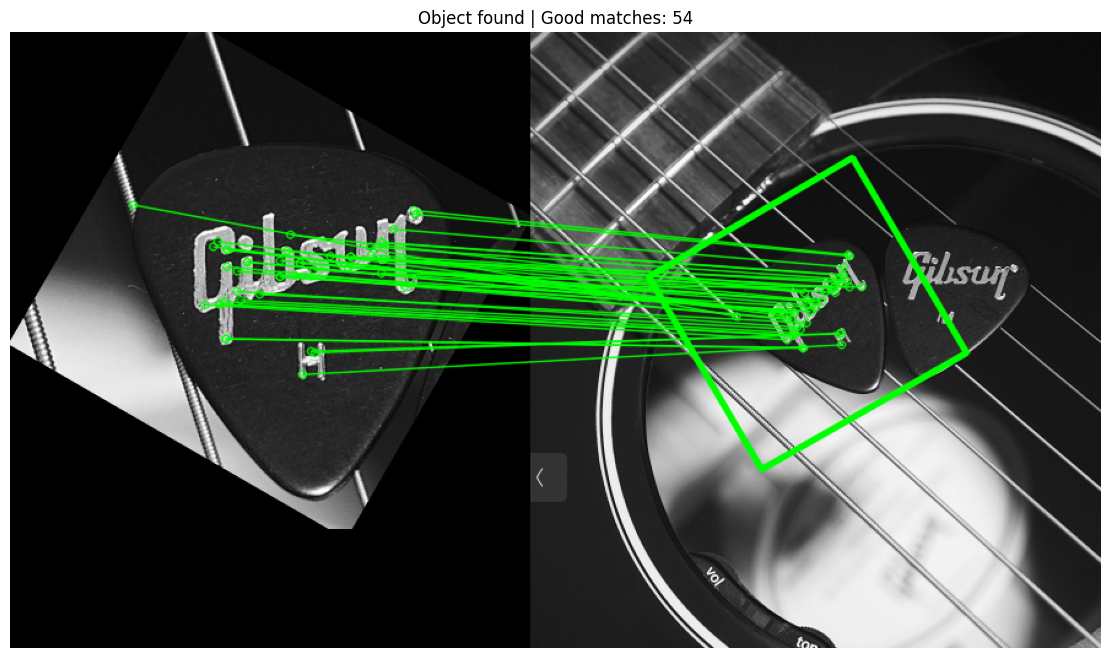

Homography matrix:
[[ 3.83972068e-01  2.25783697e-01  9.69754325e+01]
 [-2.31013223e-01  3.88426201e-01  1.99175905e+02]
 [-2.84454687e-05 -1.34896082e-06  1.00000000e+00]]
Mask shape: (54, 1)


In [20]:
if len(good) >= MIN_MATCH_COUNT:
    src_pts = np.float32([
        kp1[m.queryIdx].pt for m in good
    ]).reshape(-1, 1, 2)

    dst_pts = np.float32([
        kp2[m.trainIdx].pt for m in good
    ]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(
        src_pts,
        dst_pts,
        cv2.RANSAC,
        5.0
    )

    visualize_homography_result(
        query_img=query_rotated,
        train_img=train_img,
        kp1=kp1,
        kp2=kp2,
        good=good,
        H=H,
        mask=mask,
        min_match_count=MIN_MATCH_COUNT
    )
    print("Homography matrix:")
    print(H)

    print("Mask shape:", mask.shape)

else:
    print("Không đủ good matches để tìm Homography.")
    print("Good matches:", len(good))

In [27]:
MIN_MATCH_COUNT = 10

# ORB detector
orb = cv2.ORB_create(nfeatures=1000)

# Find keypoints and descriptors
kp1, des1 = orb.detectAndCompute(query_rotated, None)
kp2, des2 = orb.detectAndCompute(train_img, None)

print("Number of keypoints in query image:", len(kp1))
print("Number of keypoints in train image:", len(kp2))

if des1 is None or des2 is None:
    raise ValueError("Không tìm được descriptor.")

# ORB dùng binary descriptor nên dùng Hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good = []

for pair in matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < 0.75 * n.distance:
            good.append(m)

print("Good matches:", len(good))

Number of keypoints in query image: 990
Number of keypoints in train image: 1000
Good matches: 133


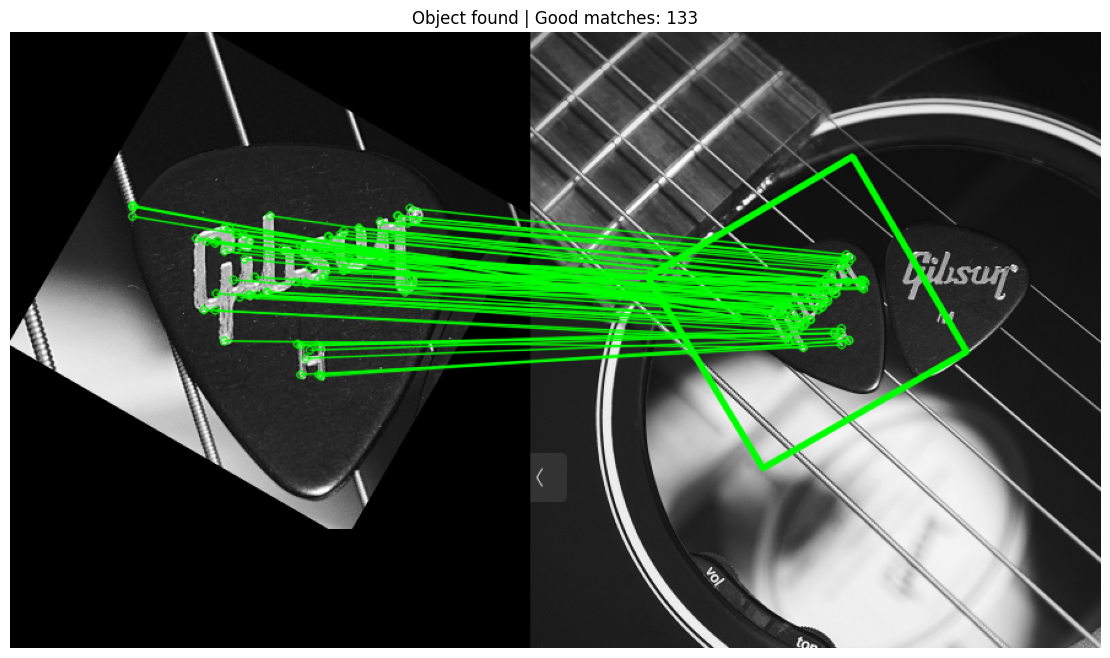

Homography matrix:
[[ 3.91667581e-01  2.36936132e-01  9.54672292e+01]
 [-2.31584017e-01  3.97875952e-01  1.99016633e+02]
 [-1.61363398e-05  2.63905926e-05  1.00000000e+00]]
Mask shape: (133, 1)


In [28]:
if len(good) >= MIN_MATCH_COUNT:
    src_pts = np.float32([
        kp1[m.queryIdx].pt for m in good
    ]).reshape(-1, 1, 2)

    dst_pts = np.float32([
        kp2[m.trainIdx].pt for m in good
    ]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(
        src_pts,
        dst_pts,
        cv2.RANSAC,
        5.0
    )

    visualize_homography_result(
        query_img=query_rotated,
        train_img=train_img,
        kp1=kp1,
        kp2=kp2,
        good=good,
        H=H,
        mask=mask,
        min_match_count=MIN_MATCH_COUNT
    )
    print("Homography matrix:")
    print(H)

    print("Mask shape:", mask.shape)

else:
    print("Không đủ good matches để tìm Homography.")
    print("Good matches:", len(good))